In [1]:
# !pip install xgboost

In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor 
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn import tree 

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

import pickle

In [3]:
Concrete = pd.read_csv("concrete.csv")

# ANALYSE THE DATA

In [5]:
Concrete.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [6]:
Concrete.shape

(1030, 9)

In [7]:
Concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [8]:
Concrete.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement (component 1)(kg in a m^3 mixture),1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
Blast Furnace Slag (component 2)(kg in a m^3 mixture),1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
Fly Ash (component 3)(kg in a m^3 mixture),1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
Water (component 4)(kg in a m^3 mixture),1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
Superplasticizer (component 5)(kg in a m^3 mixture),1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
Coarse Aggregate (component 6)(kg in a m^3 mixture),1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
Fine Aggregate (component 7)(kg in a m^3 mixture),1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
Age (day),1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
"Concrete compressive strength(MPa, megapascals)",1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


In [9]:
Concrete.corr(numeric_only=True)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
Cement (component 1)(kg in a m^3 mixture),1.000000,-0.275193,-0.397475,-0.081544,0.092771,-0.109356,-0.222720,0.081947,0.497833
Blast Furnace Slag (component 2)(kg in a m^3 mixture),-0.275193,1.000000,-0.323569,0.107286,0.043376,-0.283998,-0.281593,-0.044246,0.134824
Fly Ash (component 3)(kg in a m^3 mixture),-0.397475,-0.323569,1.000000,-0.257044,0.377340,-0.009977,0.079076,-0.154370,-0.105753
Water (component 4)(kg in a m^3 mixture),-0.081544,0.107286,-0.257044,1.000000,-0.657464,-0.182312,-0.450635,0.277604,-0.289613
Superplasticizer (component 5)(kg in a m^3 mixture),0.092771,0.043376,0.377340,-0.657464,1.000000,-0.266303,0.222501,-0.192717,0.366102
Coarse Aggregate (component 6)(kg in a m^3 mixture),-0.109356,-0.283998,-0.009977,-0.182312,-0.266303,1.000000,-0.178506,-0.003016,-0.164928
Fine Aggregate (component 7)(kg in a m^3 mixture),-0.222720,-0.281593,0.079076,-0.450635,0.222501,-0.178506,1.000000,-0.156094,-0.167249
Age (day),0.081947,-0.044246,-0.154370,0.277604,-0.192717,-0.003016,-0.156094,1.000000,0.328877
"Concrete compressive strength(MPa, megapascals)",0.497833,0.134824,-0.105753,-0.289613,0.366102,-0.164928,-0.167249,0.328877,1.000000


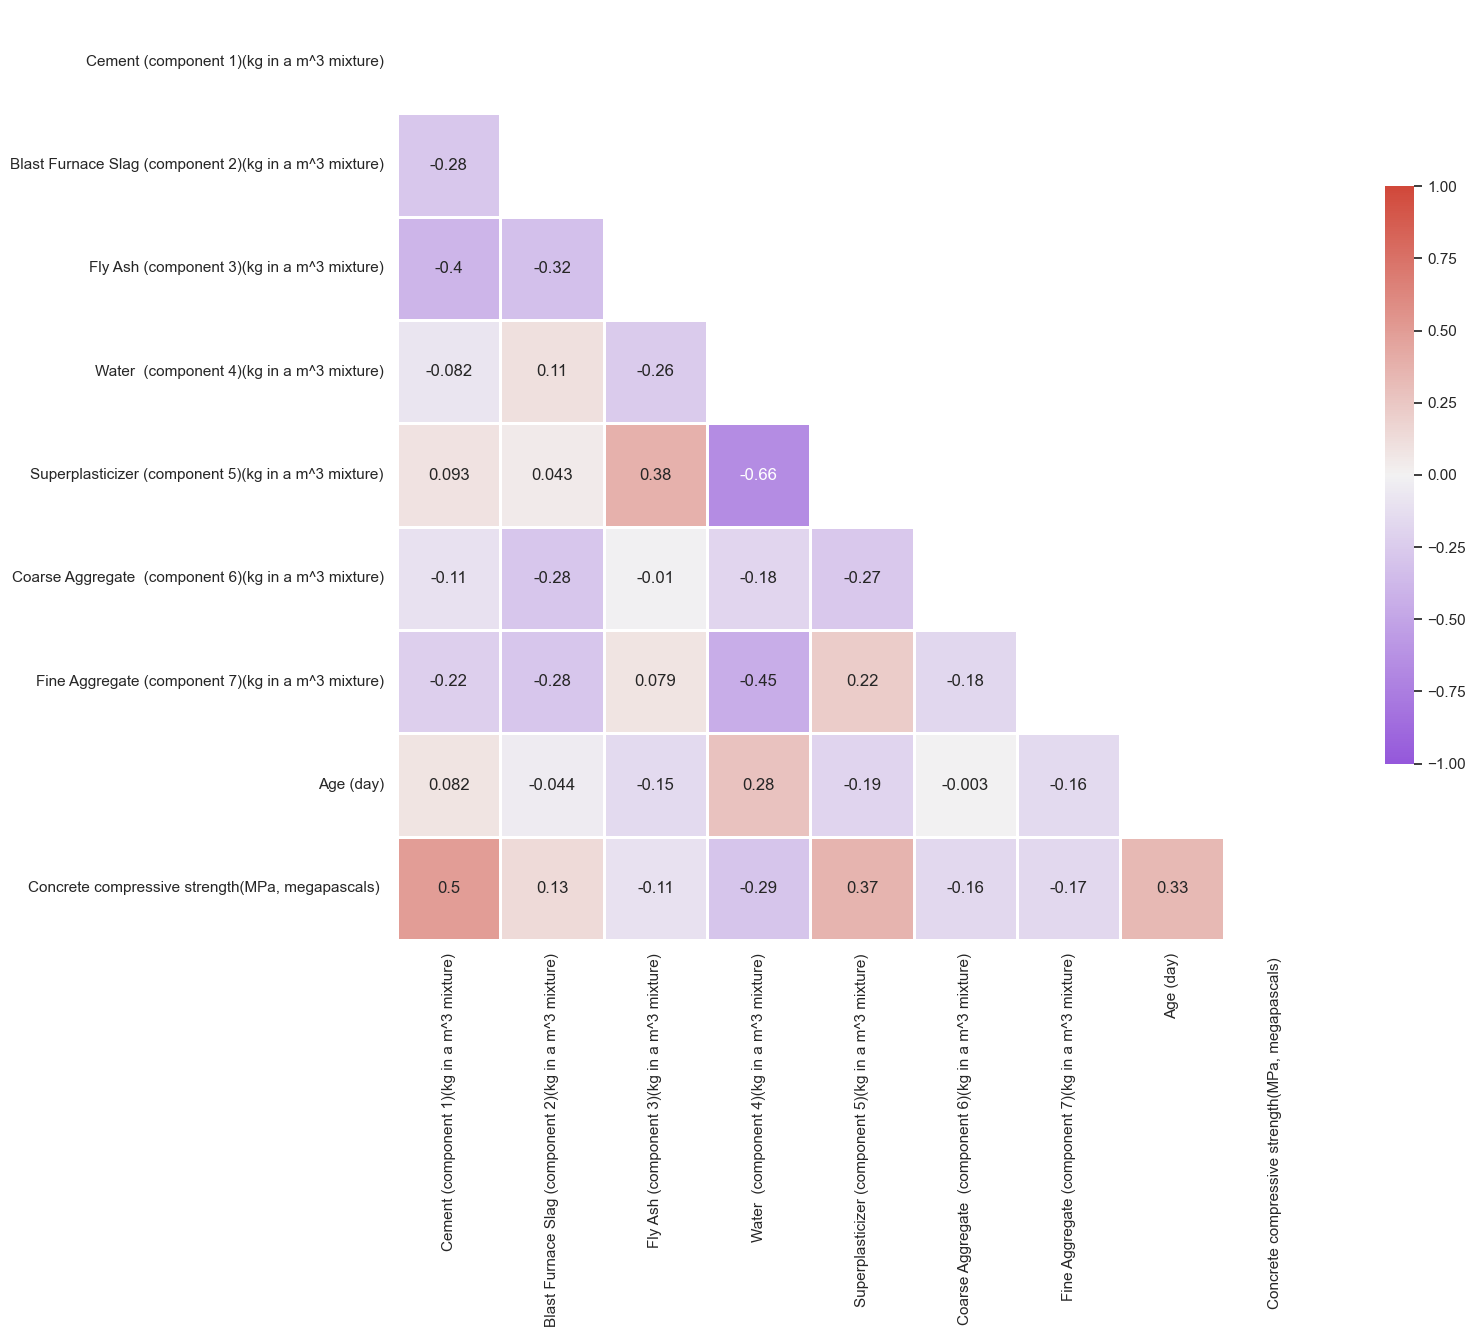

In [10]:
import seaborn as sns

correlation = Concrete.corr() 

sns.set(style="white")

mask = np.zeros_like(correlation, dtype=bool) 
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(15, 15)) 
cmap = sns.diverging_palette(1000, 15, as_cmap=True)

sns.heatmap(correlation, mask=mask, cmap=cmap, vmax=1, vmin=-1,center=0,
            square=True, linewidths=1, cbar_kws={"shrink": .5}, annot = True); 

# MISSING VALUES

In [12]:
Concrete.isna().sum()

# There is no missing value, the dataset is clean

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

# DETECTION OF OUTLIERS

In [14]:
columns = Concrete.columns

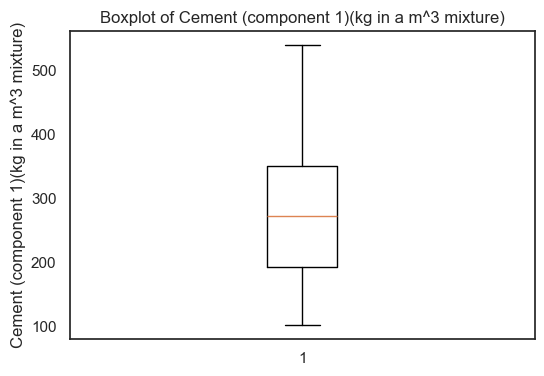

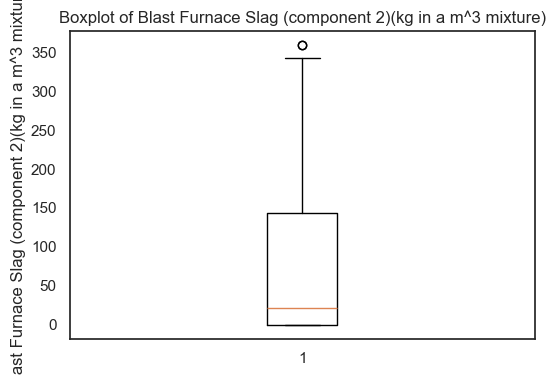

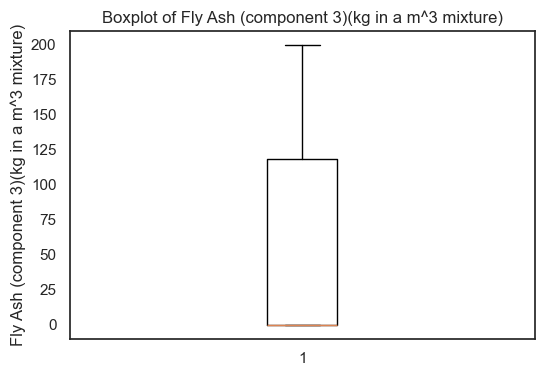

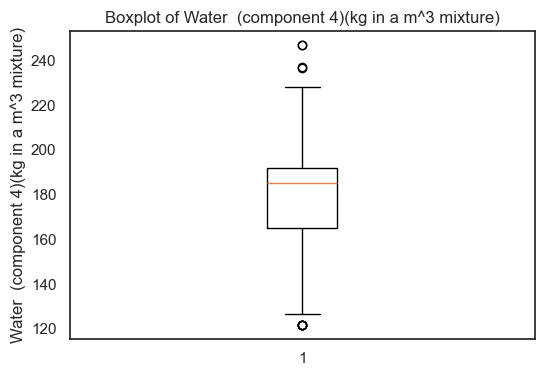

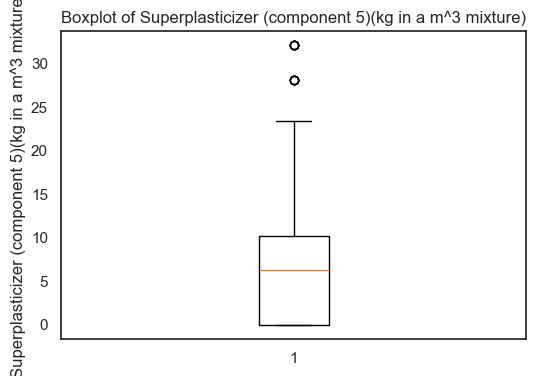

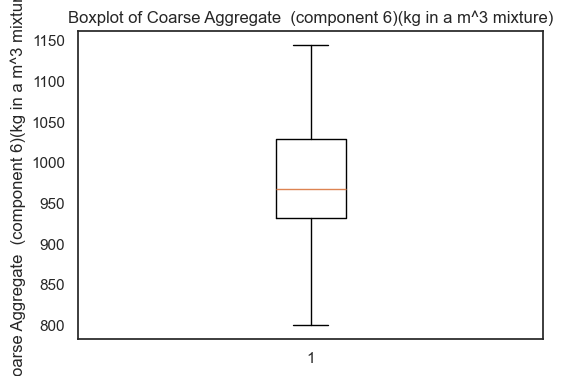

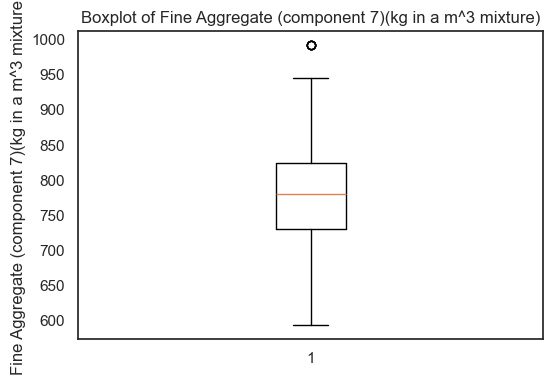

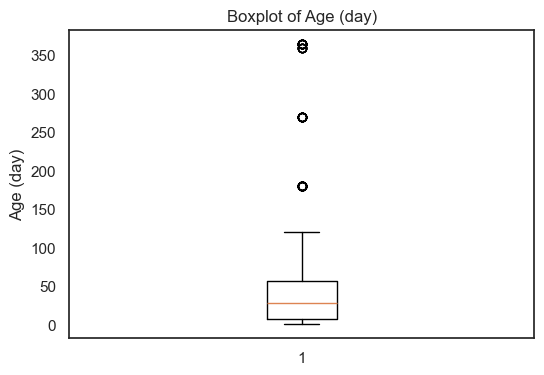

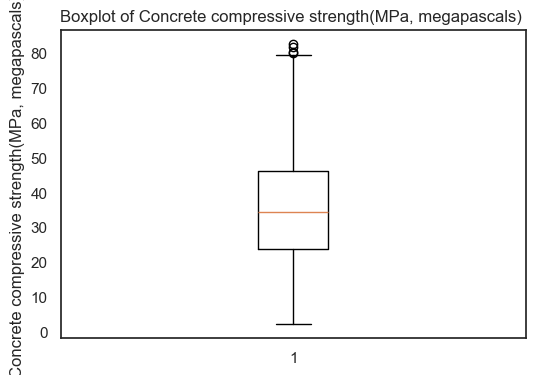

In [15]:

for col in columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(Concrete[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [16]:
z_score = 3

outliers_dict = {}

for col in columns:
    zscore = (Concrete[col] - Concrete[col].mean()) / Concrete[col].std()
    outliers = Concrete[abs(zscore) > z_score]
    outliers_dict[col] = outliers
    print(f"{col} : {len(outliers)} outliers detected")

Cement (component 1)(kg in a m^3 mixture) : 0 outliers detected
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 4 outliers detected
Fly Ash (component 3)(kg in a m^3 mixture) : 0 outliers detected
Water  (component 4)(kg in a m^3 mixture) : 2 outliers detected
Superplasticizer (component 5)(kg in a m^3 mixture) : 10 outliers detected
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 0 outliers detected
Fine Aggregate (component 7)(kg in a m^3 mixture) : 0 outliers detected
Age (day) : 33 outliers detected
Concrete compressive strength(MPa, megapascals)  : 0 outliers detected


In [17]:
for col, outliers in outliers_dict.items():
    print(outliers[col].values)

# I gone keep all the outliers values because they are not anormal in this subject, their is differents combinaisons 
# of ciments so everything is posiible

[]
[359.4 359.4 342.1 342.1]
[]
[247.  246.9]
[32.2 28.2 32.2 28.2 32.2 28.2 32.2 28.2 32.2 28.2]
[]
[]
[270 365 360 365 270 365 365 270 270 365 365 270 365 270 365 365 365 270
 270 270 270 360 365 365 360 365 365 270 360 360 270 360 270]
[]


# TRAIN TEST VALIDATION SPLIT

In [19]:
X = Concrete.drop("Concrete compressive strength(MPa, megapascals) ", axis=1)
y = Concrete['Concrete compressive strength(MPa, megapascals) '] 

features = list(X.columns)
features

['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)']

In [20]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, random_state=222, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, random_state=222, test_size=0.5)

In [21]:
print(Concrete.shape)

print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(1030, 9)
(721, 8)
(721,)
(154, 8)
(154,)
(155, 8)
(155,)


# SCALING THE DATA

In [23]:
## Data Standardization
from sklearn.preprocessing import StandardScaler

In [24]:
columns_X = ["Cement (component 1)(kg in a m^3 mixture)", "Blast Furnace Slag (component 2)(kg in a m^3 mixture)",
             "Fly Ash (component 3)(kg in a m^3 mixture)", "Water  (component 4)(kg in a m^3 mixture)",
             "Superplasticizer (component 5)(kg in a m^3 mixture)", "Coarse Aggregate  (component 6)(kg in a m^3 mixture)",
             "Fine Aggregate (component 7)(kg in a m^3 mixture)", "Age (day)"]

scaler = StandardScaler()
X_train[columns_X] = scaler.fit_transform(X_train[columns_X])

In [25]:
import pickle
with open("concrete_scaler.sav", "wb") as f:
    pickle.dump({'columns': columns_X, 'scaler': scaler}, f)

In [26]:
X_val[columns_X] = scaler.transform(X_val[columns_X])
X_test[columns_X] = scaler.transform(X_test[columns_X])

In [27]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement (component 1)(kg in a m^3 mixture),721.0,2.808664e-16,1.000694,-1.749845,-0.821309,-0.067714,0.720485,2.460289
Blast Furnace Slag (component 2)(kg in a m^3 mixture),721.0,-4.681107e-17,1.000694,-0.843975,-0.843975,-0.613574,0.822974,3.296325
Fly Ash (component 3)(kg in a m^3 mixture),721.0,5.420229e-17,1.000694,-0.832187,-0.832187,-0.832187,1.037743,2.250896
Water (component 4)(kg in a m^3 mixture),721.0,2.931851e-16,1.000694,-2.809426,-0.760354,0.194139,0.526549,3.138345
Superplasticizer (component 5)(kg in a m^3 mixture),721.0,-1.453607e-16,1.000694,-1.025833,-1.025833,-0.014124,0.641094,4.288527
Coarse Aggregate (component 6)(kg in a m^3 mixture),721.0,2.414466e-16,1.000694,-2.230659,-0.551390,-0.089912,0.807407,2.179024
Fine Aggregate (component 7)(kg in a m^3 mixture),721.0,-1.007670e-15,1.000694,-2.261051,-0.624216,0.075490,0.640782,2.746181
Age (day),721.0,2.956488e-17,1.000694,-0.656005,-0.594399,-0.270968,0.160274,4.919329


In [28]:
X_val.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement (component 1)(kg in a m^3 mixture),154.0,-0.145838,1.027802,-1.749845,-1.039817,-0.319697,0.403283,2.460289
Blast Furnace Slag (component 2)(kg in a m^3 mixture),154.0,0.089564,1.004871,-0.843975,-0.843975,-0.295276,0.896414,3.097028
Fly Ash (component 3)(kg in a m^3 mixture),154.0,0.121485,1.069833,-0.832187,-0.832187,-0.832187,1.096242,2.331531
Water (component 4)(kg in a m^3 mixture),154.0,0.101712,1.011588,-2.809426,-0.612194,0.194139,0.710206,3.133596
Superplasticizer (component 5)(kg in a m^3 mixture),154.0,0.007114,0.990545,-1.025833,-1.025833,0.077475,0.715363,3.628358
Coarse Aggregate (component 6)(kg in a m^3 mixture),154.0,-0.072510,0.969117,-2.230659,-0.656825,-0.132214,0.670566,1.922647
Fine Aggregate (component 7)(kg in a m^3 mixture),154.0,-0.087777,0.973703,-2.261051,-0.618564,-0.048875,0.351541,2.148227
Age (day),154.0,-0.004742,0.896952,-0.686807,-0.486588,-0.270968,0.160274,4.919329


In [29]:
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement (component 1)(kg in a m^3 mixture),155.0,-0.038995,0.996810,-1.689288,-0.858988,-0.086265,0.499405,2.460289
Blast Furnace Slag (component 2)(kg in a m^3 mixture),155.0,-0.040454,0.952216,-0.843975,-0.843975,-0.625094,0.666877,2.473794
Fly Ash (component 3)(kg in a m^3 mixture),155.0,0.042428,1.004664,-0.832187,-0.832187,-0.832187,1.026201,2.329950
Water (component 4)(kg in a m^3 mixture),155.0,0.105509,1.076206,-2.579113,-0.743258,0.272968,0.588283,2.663473
Superplasticizer (component 5)(kg in a m^3 mixture),155.0,-0.020739,0.915069,-1.025833,-1.025833,0.041991,0.616337,4.288527
Coarse Aggregate (component 6)(kg in a m^3 mixture),155.0,-0.106455,1.005601,-2.230659,-0.603307,-0.177336,0.682424,2.041862
Fine Aggregate (component 7)(kg in a m^3 mixture),155.0,0.052837,1.069509,-2.261051,-0.313306,0.106392,0.769543,2.746181
Age (day),155.0,0.011724,0.918383,-0.656005,-0.486588,-0.270968,0.160274,4.842322


# FITTING THE MODEL

In [31]:
## Lineare regression

from sklearn.linear_model import LinearRegression 

lin_reg_model = LinearRegression() 
lin_reg_model = lin_reg_model.fit(X_train, y_train) 

In [32]:
print("Intercept is:", lin_reg_model.intercept_)
print("\nCoefficients are:\n", lin_reg_model.coef_)

Intercept is: 35.87861138007806

Coefficients are:
 [11.0625873   7.44994026  4.69850657 -4.0052606   1.99529204  0.43433409
  0.29843149  7.27976752]


In [33]:
print(f"Our linear regression model:  \n \ny = {lin_reg_model.intercept_:.2f}"
      f"+ {lin_reg_model.coef_[0]:.2f}*{features[0]} "
      f"+ {lin_reg_model.coef_[1]:.2f}*{features[1]} "
      f"+ {lin_reg_model.coef_[2]:.2f}*{features[2]} "
      f"+ {lin_reg_model.coef_[3]:.2f}*{features[3]} "
      f"+ {lin_reg_model.coef_[4]:.2f}*{features[4]} "
      f"+ {lin_reg_model.coef_[5]:.2f}*{features[5]} "
      f"+ {lin_reg_model.coef_[6]:.2f}*{features[6]} "
      f"+ {lin_reg_model.coef_[7]:.2f}*{features[7]} "
     )

Our linear regression model:  
 
y = 35.88+ 11.06*Cement (component 1)(kg in a m^3 mixture) + 7.45*Blast Furnace Slag (component 2)(kg in a m^3 mixture) + 4.70*Fly Ash (component 3)(kg in a m^3 mixture) + -4.01*Water  (component 4)(kg in a m^3 mixture) + 2.00*Superplasticizer (component 5)(kg in a m^3 mixture) + 0.43*Coarse Aggregate  (component 6)(kg in a m^3 mixture) + 0.30*Fine Aggregate (component 7)(kg in a m^3 mixture) + 7.28*Age (day) 


In [34]:
## K nearest neighbors

from sklearn.neighbors import KNeighborsRegressor 

knn_model = KNeighborsRegressor() 
knn_model.fit(X_train, y_train) 

knn_model.n_neighbors

5

In [35]:
## Decision Tree

from sklearn.tree import DecisionTreeRegressor 

dec_tree = DecisionTreeRegressor(random_state=123) 

dec_tree_model = dec_tree.fit(X_train, y_train) 

In [36]:
from sklearn import tree

features = list(X.columns)
            
text_representation = tree.export_text(dec_tree_model, feature_names = features)

print(text_representation) 

|--- Age (day) <= -0.38
|   |--- Cement (component 1)(kg in a m^3 mixture) <= 0.68
|   |   |--- Superplasticizer (component 5)(kg in a m^3 mixture) <= 0.08
|   |   |   |--- Age (day) <= -0.63
|   |   |   |   |--- Coarse Aggregate  (component 6)(kg in a m^3 mixture) <= 0.04
|   |   |   |   |   |--- Cement (component 1)(kg in a m^3 mixture) <= -0.17
|   |   |   |   |   |   |--- Cement (component 1)(kg in a m^3 mixture) <= -0.89
|   |   |   |   |   |   |   |--- Coarse Aggregate  (component 6)(kg in a m^3 mixture) <= -0.98
|   |   |   |   |   |   |   |   |--- Blast Furnace Slag (component 2)(kg in a m^3 mixture) <= 0.62
|   |   |   |   |   |   |   |   |   |--- value: [4.78]
|   |   |   |   |   |   |   |   |--- Blast Furnace Slag (component 2)(kg in a m^3 mixture) >  0.62
|   |   |   |   |   |   |   |   |   |--- value: [4.57]
|   |   |   |   |   |   |   |--- Coarse Aggregate  (component 6)(kg in a m^3 mixture) >  -0.98
|   |   |   |   |   |   |   |   |--- Cement (component 1)(kg in a m^3 mi

In [37]:
dec_tree_model.tree_.max_depth

18

In [38]:
## Random Forest - Bagging

from sklearn.ensemble import RandomForestRegressor 

rand_for_model = RandomForestRegressor(random_state=123) 

rand_for_model.fit(X_train, y_train) 

RandomForestRegressor(random_state=123)

In [39]:
rand_for_model.n_estimators 

100

In [40]:
r = tree.export_text(rand_for_model.estimators_[0], feature_names=features) 

print(r)

|--- Age (day) <= -0.06
|   |--- Cement (component 1)(kg in a m^3 mixture) <= -0.28
|   |   |--- Age (day) <= -0.54
|   |   |   |--- Cement (component 1)(kg in a m^3 mixture) <= -0.89
|   |   |   |   |--- Coarse Aggregate  (component 6)(kg in a m^3 mixture) <= 0.20
|   |   |   |   |   |--- Blast Furnace Slag (component 2)(kg in a m^3 mixture) <= 0.97
|   |   |   |   |   |   |--- Cement (component 1)(kg in a m^3 mixture) <= -1.50
|   |   |   |   |   |   |   |--- value: [4.57]
|   |   |   |   |   |   |--- Cement (component 1)(kg in a m^3 mixture) >  -1.50
|   |   |   |   |   |   |   |--- Blast Furnace Slag (component 2)(kg in a m^3 mixture) <= 0.45
|   |   |   |   |   |   |   |   |--- value: [4.78]
|   |   |   |   |   |   |   |--- Blast Furnace Slag (component 2)(kg in a m^3 mixture) >  0.45
|   |   |   |   |   |   |   |   |--- value: [4.90]
|   |   |   |   |   |--- Blast Furnace Slag (component 2)(kg in a m^3 mixture) >  0.97
|   |   |   |   |   |   |--- Blast Furnace Slag (component 2)

In [41]:
for i in range(10):
    print(rand_for_model.estimators_[i].tree_.max_depth)

19
18
19
16
17
18
18
18
18
19


In [42]:
## Gradient Boosting trees

from sklearn.ensemble import GradientBoostingRegressor 

grad_boost_model = GradientBoostingRegressor(random_state=123)

grad_boost_model.fit(X_train, y_train) 

GradientBoostingRegressor(random_state=123)

In [43]:
grad_boost_model.n_estimators 

100

In [44]:
## XGBoost

from xgboost import XGBRegressor 

xgb_model = XGBRegressor(random_state=123, n_estimators=100) 
    
xgb_model.fit(X_train.values, y_train) 


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
xgb_model.n_estimators 

100

# EVALUATION MODEL

In [47]:
predictions_lr = lin_reg_model.predict(X_val)
predictions_knn = knn_model.predict(X_val)
predictions_dt = dec_tree_model.predict(X_val)
predictions_rf = rand_for_model.predict(X_val)
predictions_gbm = grad_boost_model.predict(X_val)
predictions_xgb = xgb_model.predict(X_val)

In [48]:
prediction_df = pd.DataFrame({'predictions_lr': predictions_lr,
                              'predictions_knn': predictions_knn,
                              'predictions_dt': predictions_dt,
                              'predictions_rf': predictions_rf,
                              'predictions_gbm': predictions_gbm,
                              'predictions_xgb': predictions_xgb,
                              'true_values': y_val
                             })
prediction_df

,predictions_lr,predictions_knn,predictions_dt,predictions_rf,predictions_gbm,predictions_xgb,true_values
773,31.379577,37.049820,37.437857,36.867295,35.816703,36.912411,37.424757
887,35.655186,37.760394,38.630651,37.631497,38.402638,37.780159,40.679084
830,41.718736,37.276934,33.762261,34.773798,35.492297,34.517574,33.756745
675,24.199227,37.269074,43.250829,37.732633,34.542277,32.976349,32.532925
634,21.059218,16.614993,20.870439,25.493109,25.701073,22.330559,24.497082
...,...,...,...,...,...,...,...
155,56.003221,75.297674,77.297154,76.923183,76.539668,77.435860,77.297154
515,20.067914,16.276755,23.245191,25.257686,24.400876,20.563999,21.966705
842,27.862188,28.102628,13.293097,14.965139,15.352249,15.432519,15.568368
382,46.700978,40.110956,55.944083,51.114197,41.413225,54.430565,64.017847


In [49]:
from sklearn.metrics import r2_score

print("R square for Linear regression model is:", r2_score(y_val, predictions_lr))
print("R square for K nearest neighbors model is:", r2_score(y_val, predictions_knn))
print("R square for Decision tree model is:", r2_score(y_val, predictions_dt))
print("R square for Random forest model is:", r2_score(y_val, predictions_rf))
print("R square for Gradient boosting model is:", r2_score(y_val, predictions_gbm))
print("R square for eXtreme Gradient Boosting model is:", r2_score(y_val, predictions_xgb))

R square for Linear regression model is: 0.6367083523023449
R square for K nearest neighbors model is: 0.6731814548106856
R square for Decision tree model is: 0.8538159738146132
R square for Random forest model is: 0.9087855126240775
R square for Gradient boosting model is: 0.8938547326751913
R square for eXtreme Gradient Boosting model is: 0.9254415182939872


In [50]:
# XGBoost have the best R2 square, he explain most of the variances of the data

In [51]:
predictions_lr_train = lin_reg_model.predict(X_train)
predictions_knn_train = knn_model.predict(X_train)
predictions_dt_train = dec_tree_model.predict(X_train)
predictions_rf_train = rand_for_model.predict(X_train)
predictions_gbm_train = grad_boost_model.predict(X_train)
predictions_xgb_train = xgb_model.predict(X_train)

print("R square for Linear regression model is:", r2_score(y_train, predictions_lr_train))
print("R square for K nearest neighbors model is:", r2_score(y_train, predictions_knn_train))
print("R square for Decision tree model is:", r2_score(y_train, predictions_dt_train))
print("R square for Random forest model is:", r2_score(y_train, predictions_rf_train))
print("R square for Gradient boosting model is:", r2_score(y_train, predictions_gbm_train))
print("R square for eXtreme Gradient Boosting model is:", r2_score(y_train, predictions_xgb_train))

R square for Linear regression model is: 0.616339085193924
R square for K nearest neighbors model is: 0.7995281179225542
R square for Decision tree model is: 0.9963117662136679
R square for Random forest model is: 0.98428315138804
R square for Gradient boosting model is: 0.9525504555863369
R square for eXtreme Gradient Boosting model is: 0.9956278209912134


In [52]:
# DT and  RF are good for memorazing training examples. 

In [53]:
# Calculated The error rate

from sklearn.metrics import root_mean_squared_error 

print("RMSE for Linear regression model is:", root_mean_squared_error(y_val, predictions_lr))
print("RMSE for K nearest neighbors model is:", root_mean_squared_error(y_val, predictions_knn))
print("RMSE for Decision tree model is:", root_mean_squared_error(y_val, predictions_dt))
print("RMSE for Random forest model is:", root_mean_squared_error(y_val, predictions_rf))
print("RMSE for Gradient boosting model is:", root_mean_squared_error(y_val, predictions_gbm))
print("RMSE for eXtreme Gradient Boosting model is:", root_mean_squared_error(y_val, predictions_xgb))

RMSE for Linear regression model is: 9.951575838016677
RMSE for K nearest neighbors model is: 9.438815489509414
RMSE for Decision tree model is: 6.312684870206053
RMSE for Random forest model is: 4.986502730873556
RMSE for Gradient boosting model is: 5.379160069429106
RMSE for eXtreme Gradient Boosting model is: 4.508298651785866


In [54]:
from sklearn.metrics import mean_absolute_error 

print("MAE for Linear regression model is:", mean_absolute_error(y_val, predictions_lr))
print("MAE for K nearest neighbors model is:", mean_absolute_error(y_val, predictions_knn))
print("MAE for Decision tree model is:", mean_absolute_error(y_val, predictions_dt))
print("MAE for Random forest model is:", mean_absolute_error(y_val, predictions_rf))
print("MAE for Gradient boosting model is:", mean_absolute_error(y_val, predictions_gbm))
print("MAE for eXtreme Gradient Boosting model is:", mean_absolute_error(y_val, predictions_xgb))

MAE for Linear regression model is: 8.088405139483086
MAE for K nearest neighbors model is: 7.258319415651891
MAE for Decision tree model is: 4.492614956357794
MAE for Random forest model is: 3.640193743576082
MAE for Gradient boosting model is: 4.080942869092097
MAE for eXtreme Gradient Boosting model is: 3.219381897705962


In [55]:
# XGBoost also have the lowest RMSE and MAE, so this is the best model

# AUTOMATISATION 

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [('Linear Regression', LinearRegression), 
          ('K nearest neighbors', KNeighborsRegressor), 
          ('Decision Tree', DecisionTreeRegressor), 
          ('Random Forest', RandomForestRegressor),
          ('Gradient Boosting Tree', GradientBoostingRegressor),
          ('XGB Regressor', XGBRegressor),
         ]
models

[('Linear Regression', sklearn.linear_model._base.LinearRegression),
 ('K nearest neighbors', sklearn.neighbors._regression.KNeighborsRegressor),
 ('Decision Tree', sklearn.tree._classes.DecisionTreeRegressor),
 ('Random Forest', sklearn.ensemble._forest.RandomForestRegressor),
 ('Gradient Boosting Tree', sklearn.ensemble._gb.GradientBoostingRegressor),
 ('XGB Regressor', xgboost.sklearn.XGBRegressor)]

In [58]:
metrics = []
for name, model in models:
    ml_model = model().fit(X_train, y_train)
    pred=ml_model.predict(X_val)
    metrics.append((name, r2_score(y_val, pred), root_mean_squared_error(y_val, pred), mean_absolute_error(y_val, pred)))

metrics = pd.DataFrame(metrics, columns=['Model', 'R square', 'Root mean squared error', 'Mean absolute error'])

metrics

,Model,R square,Root mean squared error,Mean absolute error
0,Linear Regression,0.636708,9.951576,8.088405
1,K nearest neighbors,0.673181,9.438815,7.258319
2,Decision Tree,0.853851,6.311921,4.261335
3,Random Forest,0.908220,5.001929,3.569328
4,Gradient Boosting Tree,0.894020,5.374972,4.078165
5,XGB Regressor,0.925442,4.508299,3.219382


# HYPERPARAMETER TUNNING

In [60]:
# For this step we will focus only on this models because their R2 are better than the 3 others

# Random Forest	
# Gradient Boosting Tree
# XGB Regressor

In [61]:
## Automated hyperparameter tunning

### Grid Search

In [62]:
### Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

rf_grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(estimator=rf,
                       param_grid=rf_grid_params,
                       cv=10,
                       verbose=1,
                       n_jobs=-1)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)


Fitting 10 folds for each of 18 candidates, totalling 180 fits
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [63]:
### Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb_grid_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(estimator=gb,
                       param_grid=gb_grid_params,
                       cv=10,
                       verbose=1,
                       n_jobs=-1)

gb_grid.fit(X_train, y_train)
print(gb_grid.best_params_)


Fitting 10 folds for each of 18 candidates, totalling 180 fits
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


In [64]:
### XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

xgb_grid_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(estimator=xgb,
                        param_grid=xgb_grid_params,
                        cv=10,
                        verbose=1,
                        n_jobs=-1)

xgb_grid.fit(X_train, y_train)
print(xgb_grid.best_params_)


Fitting 10 folds for each of 8 candidates, totalling 80 fits
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [65]:
models = {
    "Random Forest": rf_grid,
    "Gradient Boosting": gb_grid,
    "XGB Regressor": xgb_grid
}

for name, grid in models.items():
    best_model = grid.best_estimator_      
    y_pred = best_model.predict(X_test)    
    r2 = r2_score(y_test, y_pred)          
    print(f"{name} R²: {r2:.4f}")


Random Forest R²: 0.8992
Gradient Boosting R²: 0.9462
XGB Regressor R²: 0.9371


In [66]:
for name, grid in models.items():
    best_model = grid.best_estimator_      
    y_pred = best_model.predict(X_test)    
    rmse = root_mean_squared_error(y_test, y_pred)          
    print(f"{name} RMSE: {rmse:.4f}")

Random Forest RMSE: 5.1829
Gradient Boosting RMSE: 3.7880
XGB Regressor RMSE: 4.0964


In [67]:
for name, grid in models.items():
    best_model = grid.best_estimator_      
    y_pred = best_model.predict(X_test)    
    mae = mean_absolute_error(y_test, y_pred)          
    print(f"{name} MAE: {mae:.4f}")

Random Forest MAE: 3.6157
Gradient Boosting MAE: 2.6044
XGB Regressor MAE: 2.7578


# EVALUATION ON THE TEST DATA

In [69]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

In [70]:
rf_final_model = gb_grid
rf_model = rf_final_model.fit(X_train_final, y_train_final) 

predictions_rf = rf_model.predict(X_test)

Fitting 10 folds for each of 18 candidates, totalling 180 fits


In [71]:
r2 = r2_score(y_test, predictions_rf) 
RMSE = root_mean_squared_error(y_test, predictions_rf)
MAE = mean_absolute_error(y_test, predictions_rf)

print("R square for final model is", r2)
print("Root mean squared error for final model is", RMSE)
print("Mean absolute error for final model is", MAE)

R square for final model is 0.9561126336605238
Root mean squared error for final model is 3.4204734598593904
Mean absolute error for final model is 2.361270786372928


# DEPLOYING THE MODEL

In [73]:
import pickle

with open("finalized_regression_model.sav", "wb") as f:
    pickle.dump(rf_model, f)

In [74]:
new_data = pd.read_csv("concrete.csv", usecols=lambda c: c != "Concrete compressive strength(MPa, megapascals) ")

In [75]:
new_data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [76]:
import pickle

with open("concrete_scaler.sav", "rb") as f:
    scaler_data = pickle.load(f)
scaler_data

{'columns': ['Cement (component 1)(kg in a m^3 mixture)',
  'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
  'Fly Ash (component 3)(kg in a m^3 mixture)',
  'Water  (component 4)(kg in a m^3 mixture)',
  'Superplasticizer (component 5)(kg in a m^3 mixture)',
  'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
  'Fine Aggregate (component 7)(kg in a m^3 mixture)',
  'Age (day)'],
 'scaler': StandardScaler()}

In [77]:
type(scaler_data["scaler"])

sklearn.preprocessing._data.StandardScaler

In [78]:
def preprocess_concrete_data(df):
    with open("concrete_scaler.sav", "rb") as f:
        scaler_data = pickle.load(f)
    
    columns = scaler_data['columns']
    scaler = scaler_data['scaler']
    
    df[columns] = scaler.transform(df[columns])
    return df

In [79]:
new_data = preprocess_concrete_data(new_data)

new_data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,2.460289,-0.843975,-0.832187,-0.898066,-0.613227,0.833045,-1.230963,-0.270968
1,2.460289,-0.843975,-0.832187,-0.898066,-0.613227,1.025328,-1.230963,-0.270968
2,0.465762,0.797630,-0.832187,2.236088,-1.025833,-0.551390,-2.261051,3.456189
3,0.465762,0.797630,-0.832187,2.236088,-1.025833,-0.551390,-2.261051,4.919329
4,-0.821309,0.681277,-0.832187,0.526549,-1.025833,0.043404,0.647063,4.842322


In [80]:
with open("finalized_regression_model.sav", "rb") as f:
    loaded_model = pickle.load(f)

loaded_model

GridSearchCV(cv=10, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             verbose=1)

In [81]:
estimated_CCS = loaded_model.predict(new_data)

In [82]:
new_data['estimated_compressive_strenght'] = estimated_CCS

new_data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),estimated_compressive_strenght
0,2.460289,-0.843975,-0.832187,-0.898066,-0.613227,0.833045,-1.230963,-0.270968,62.835056
1,2.460289,-0.843975,-0.832187,-0.898066,-0.613227,1.025328,-1.230963,-0.270968,61.589881
2,0.465762,0.797630,-0.832187,2.236088,-1.025833,-0.551390,-2.261051,3.456189,40.358483
3,0.465762,0.797630,-0.832187,2.236088,-1.025833,-0.551390,-2.261051,4.919329,41.253966
4,-0.821309,0.681277,-0.832187,0.526549,-1.025833,0.043404,0.647063,4.842322,44.079939


In [83]:
new_data.to_csv('Concrete_Data_Predictions.csv', sep=';', index=None, header=True) 